# Apuntes de clase

## ¿Que es Machine Learning?
Maquina que está aprendiendo patrones, de los datos que le damos, con el objetivo de que haga una predicción o decisión sobre datos nuevos.

### AI
El más global de los conceptos, (Artificial Inteligence). Son máquinas que intentan imitar la inteligencia humana y las funciones cognitivas humanas a través de algoritmos.

### Machine learning
Maquinas que hacen predicciones que minimicen los errores que surgen al simplemente adivinar.

### Deep Learning
Utiliza redes neuronales para imitar la funcionalidad, al igual que un cerebro humano.

### LLM's

Basados en aprendizaje profundo y modelos de transformadores, los LLM analizan patrones en los datos para predecir la siguiente palabra en una secuencia (i.e. Chatbots)


## Funciones de Machine Learning

* Paso 1: Reconocer(i.e. Diferenciar gatos de perros)
* Paso 2: Agrupar (Separar por categorias, como grupo gatos o grupo perros)
* Paso 3: Predecir (Predecir si las imagenes están correctas, por ejemplo si al gatito le faltan los ojos, etc.)
* Paso 4: Simplificar (Identificar que hace un gato ser un gato, prejitas, tamaño, etc.)

## Tres tipos de aprendizajes

* Aprendizaje supervisado: la máquina aprende a partir de un set de datos ya etiquetados y hace predicciones en un nuevo set de datos.

* Aprendizaje no supervisado: la máquina busca e infiere sus propios patrones y agrupaciones a partir de datos no etiquetados.

* Aprendizaje por refuerzo: la máquina toma decisiones que logran el resultado óptimo. (Ej. Las maquinas que aprenden a jugar ajedrez, y el incentivo es ganar.)

## Lenguaje Machine Learning

* "Features" (características): Cantidades observables, conocido para todos los datos.

* "Label" o "Target" (etiquetas): la propiedad que queremos predecir (si acaso existe).

* "Instances" (ejemplos): objetos en nuestro set de datos.

La calidad de datos y el tamaño de la muestra es crucial en aprendizaje supervisado.

## Para construir un modelo de aprendizaje supervisado:
1) **Organizar los datos** en matrices o vectores de características y objetivos (targets).

2) Dividirlos en un **conjunto de entrenamiento y un conjunto de prueba**.

3) **Seleccionar el algoritmo de aprendizaje automático** que se desée utilizar y sus parámetros

4) **Construir el modelo** aplicando el algoritmo seleccionado al conjunto de entrenamiento. (en scikit-learn corresponde al "*.fit*")

5) **Aplicar el modelo** a las características de los datos de prueba para predecir la propiedad objetivo de los datos de prueba. (en scikit-learn corresponde al "*.predict*")

6) **Estimar el rendimiento del modelo** utilizando alguna métrica de evaluación apropiada para comparar la propiedad objetivo predicha con la real de los datos de prueba.

7) **Optimizar** el funcionamiento o **repetir** desde el paso uno en caso que no esté funcionando.


## Entrenamiento y Prueba

Para aprendizaje supervisado, es común dividir el set de aprendizaje en un set de entrenamiento (training set) y un test de prueba (test set), seleccionados aleatoriamente. (ej: ~30% test, ~70% training)

* Train set: para construir el modelo
* Test set: para evaluar la performance del modelo
* Train score (error): performance en el trein set
* Test score (error): performance en el test set
* Generalization score(error): performance en datos nuevos

## Clasificación

Hablamos de "clasificación" cuando los resultados son una variables discretas( autos, etc.)

## Regresión

Hablamos de "regresión" cuando el resultado es una variable continua (medidas del portal inmobiliario)

## Ciclo de vida de un proyecto de ML

Definición del problema --> Recolección de datos --> Exploración y limpieza de datos --> Ingeniería de características --> Selección y entrenamiento del modelo --> Evaluación del modelo --> Interpretación y mejora --> Despliege y mantenimiento/Publicación.

# Inferencia estadística vs Aprendizaje de máquinas

Pía Amigo, 2026

### Parte 1: Ajuste de recta

(Adaptado de Viviana Acquaviva (2023))

**Objetivo:** Resolver el mismo problema con dos estrategias distintas y comparar sus resultados.

**Nombre(s): Esteban Sánchez Muñoz**

In [58]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Parámetros para figuras de alta calidad
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

np.random.seed(16)  # semilla fija para reproducibilidad

x = np.arange(10)
y = 2*x + 5 + np.random.randn(10)  # datos con scatter gaussiano
y = np.round(y, 1)
print(y)

[ 5.1  5.5  8.4 11.1 11.8 14.4 16.1 19.5 20.2 23.1]


Los datos corresponden al movimiento de un auto con rapidez constante,
donde el eje $x$ es tiempo (en segundos) y el eje $y$ es distancia (en metros).

**Pregunta:** A partir de estos datos queremos predecir $d(t=12\text{ s})$.
Antes de escribir código: ¿cómo resolverías este problema? Describe tu estrategia con palabras.

**Tu respuesta:**

Lo primero sería visualizar los datos y encontrar un ajuste para los mejores valores de posición inicial y velocidad. Luego se aplicaría el modelo para predecir la posición en t=12s

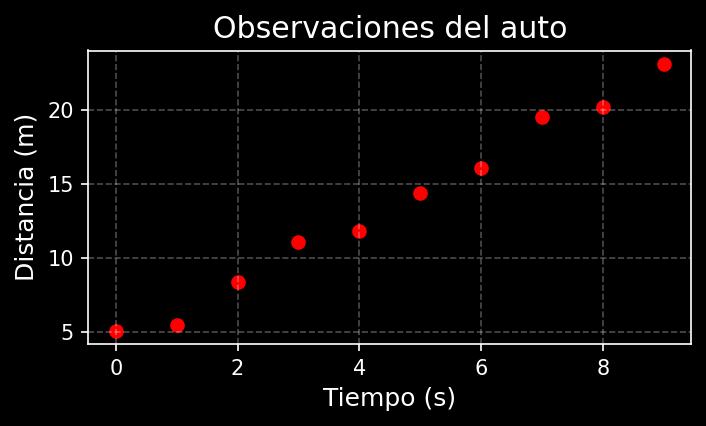

In [59]:
# Visualiza los datos
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Observaciones del auto')
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)

## Parte 1: Inferencia estadística

Sabemos que la relación entre distancia y tiempo para un auto con rapidez constante es:
$$d = d_0 + v \cdot t$$

Este modelo tiene dos parámetros: $d_0$ (posición inicial) y $v$ (velocidad).
Nuestro objetivo es **encontrar los valores de $d_0$ y $v$** que mejor explican los datos.

### 1a. Búsqueda por grilla

Una estrategia es probar muchas combinaciones de parámetros y quedarse con la que
minimiza el **error cuadrático medio (MSE) (Mínimos cuadrados)**:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2$$

In [60]:
# Definimos la grilla de parámetros a explorar
m_range = np.linspace(0, 5, 100)   # posibles velocidades
b_range = np.linspace(0, 10, 100)  # posibles posiciones iniciales

best_mse = np.inf
bestm, bestb = 0, 0

# Completa el loop: para cada combinación (m, b),
# calcula el MSE y guarda los mejores parámetros
for m in m_range:
    for b in b_range:
      # Tu código acá:
      # Calculamos la posición:
      d = b + m * x
      # Calculamos el error cuadrático medio
      mse = np.mean((y - d)**2)
      # encontramos el mejor mse como el valor dode el error sea mínimo.
      best_mse = min(best_mse, mse)
      # si es igual al modelo, se asignan esos valores
      if best_mse == mse:
        bestm = m
        bestb = b




print(f'Mejor pendiente (velocidad):     {bestm:.3f} m/s')
print(f'Mejor intercepto (pos. inicial): {bestb:.3f} m')
print(f'MSE mínimo: {best_mse:.4f}')

d12 = bestm * 12 + bestb
print(f'd(t=12): {d12:.2f} m')

Mejor pendiente (velocidad):     2.071 m/s
Mejor intercepto (pos. inicial): 4.242 m
MSE mínimo: 0.3699
d(t=12): 29.09 m


<details>
<summary>Ayuda</summary>

Dentro del loop calcula la predicción y el MSE:
```python
y_pred = m * x + b
mse = np.mean((y - y_pred)**2)
```
Luego comparas con `best_mse` y actualizas si encontraste algo mejor.
</details>

**¿Cuáles son los valores encontrados? ¿Son razonables físicamente?**
Con este modelo, ¿cuánto vale $d(t=12\text{ s})$?

- `bestm` = 2.071 m/s
- `bestb` = 4.242 m/s
- $d(t=12)$ = 29.09 m

Lo cual tiene sentido físicamente, ya que los valores iniciales del modelo para v= 2m/s y d_0= 5m/s dan d=29m, su calculamos a mano para t= 12s. Lo cual no da valores muy similares.

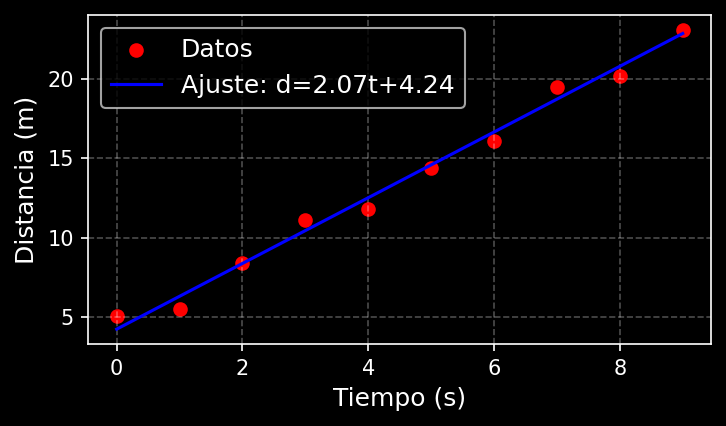

In [61]:
# Grafica los datos y la recta con los mejores parámetros
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red', label='Datos')
plt.plot(x, bestm*x + bestb, c='b', label=f'Ajuste: d={bestm:.2f}t+{bestb:.2f}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)

### 1b. Ajuste con incertezas

En astronomía las mediciones siempre tienen incertezas.
Cuando las incluimos, los puntos más precisos (menor $\sigma_i$) deben tener
**más peso** en el ajuste. La función a minimizar se convierte en el $\chi^2$:

$$\chi^2 = \sum_{i=1}^{N} \frac{(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2}{\sigma_i^2}$$

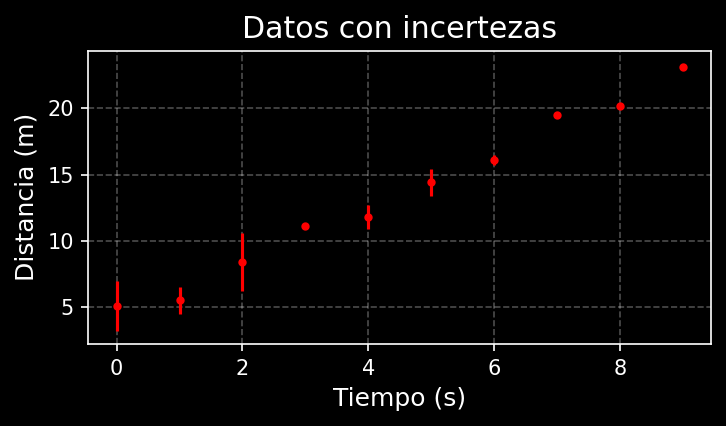

In [62]:
np.random.seed(10)
dy = np.random.randn(10) * np.sqrt(2)  # incertezas aleatorias

plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Datos con incertezas')
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)
plt.tight_layout()

In [63]:
# Encuentra los mejores parámetros usando chi2 en lugar de MSE
best_chi2 = np.inf
bestm_werr, bestb_werr = 0, 0

for m in m_range:
    for b in b_range:
      # Tu código acá:
      # Se calcula la incerteza.
      chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
      # Si la incerteza es menor al chi2 modelo, selecionamos esos valores como el mejor modelo.
      if chi2 < best_chi2:
        best_chi2 = chi2
        bestm_werr = m
        bestb_werr = b


print(f'Mejor pendiente (con incertezas):  {bestm_werr:.3f} m/s')
print(f'Mejor intercepto (con incertezas): {bestb_werr:.3f} m')

Mejor pendiente (con incertezas):  1.818 m/s
Mejor intercepto (con incertezas): 5.657 m


<details>
<summary> Ayuda</summary>

```python
chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
```
</details>

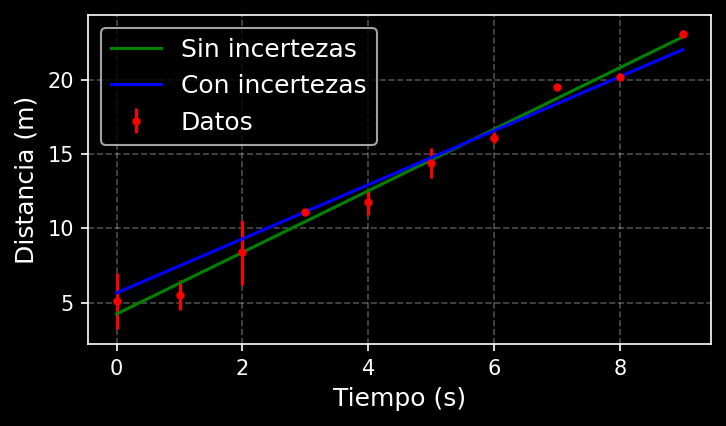

In [64]:
# Comparamos ambos ajustes
plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ', label='Datos')
plt.plot(x, bestb + bestm * x, c='g', label='Sin incertezas')
plt.plot(x, bestb_werr + bestm_werr * x, c='b', label='Con incertezas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)

**Pregunta: ¿Cambiaron mucho los parámetros al incluir incertezas? ¿Tiene sentido ese cambio?**

**Tu respuesta:**

Cambian un poco. Y esto tiene sentido ya que al utilizar chi cuadrado los datos que tienen mayor incerteza influyen menos al aplicarle el modelo con incertezas.


## Parte 2: Machine Learning

En ML **no asumimos la forma del modelo**. Le damos los datos a un algoritmo
y él aprende la relación entre input ($t$) y output ($d$) directamente.

Probaremos dos modelos:
- [**Regresión lineal**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) (`LinearRegression`): aprende la misma recta, pero sin que nosotros definamos el modelo físico.
- [**kNN Regressor**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) (`KNeighborsRegressor`): predice el valor de un punto nuevo como el **promedio de sus $k$ vecinos más cercanos**. No asume ninguna forma funcional.



### 2a. División train/test

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

np.random.seed(10)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=3)

print(f'Entrenamiento: {X_train} → {y_train}')
print(f'Prueba:        {X_test} → {y_test}')

Entrenamiento: [6 3 1 0 7 4 9] → [16.1 11.1  5.5  5.1 19.5 11.8 23.1]
Prueba:        [8 2 5] → [20.2  8.4 14.4]


**Pregunta:** ¿Por qué separamos los datos en train y test?
¿Qué pasaría si evaluáramos el modelo en los mismos datos con los que lo entrenamos?

**Tu respuesta:**

Porque de esta manera podemos ver que tan bien ajusta los datos el modelo, para luego compararlo con los datos de prueba. Y la justificación de proporción de ambos se debe a que no tiene sentido que el modelo sepa lo que debe obtener antes de realizar el entrenamiento. Por lo que los modelos serán muy buenos, pero "irreales". Y por otro lado sin los datos de prueba el modelo no puede saber a que debe llegar, y los resultados que obtendríamos no serían buenos.

### 2b. Entrenar y evaluar ambos modelos

In [66]:
regmodel = LinearRegression()
knnmodel = KNeighborsRegressor(n_neighbors=3)

# Entrenamos con los datos de train y predecimos en test
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
y_pred_knn = knnmodel.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1)) # Tu código acá

print('Real:        ', y_test)
print('Reg. Lineal: ', np.round(y_pred_reg, 2))
print('kNN (k=3):   ', np.round(y_pred_knn, 2))

Real:         [20.2  8.4 14.4]
Reg. Lineal:  [20.89  8.42 14.66]
kNN (k=3):    [19.57  7.23 15.8 ]


<details>
<summary>Ayuda</summary>

El patrón de sklearn siempre es el mismo:
```python
modelo.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1))
```
</details>

In [67]:
# Calculamos el MSE para cada modelo
mse_reg = np.mean((y_test - y_pred_reg)**2)
mse_knn = np.mean((y_test - y_pred_knn)**2)

print(f'MSE Regresión Lineal: {mse_reg:.4f}')
print(f'MSE kNN (k=3):        {mse_knn:.4f}')

MSE Regresión Lineal: 0.1820
MSE kNN (k=3):        1.2407


**Pregunta: ¿Cuál modelo tiene menor MSE? Con solo 3 puntos de test, ¿qué tan confiable es esta comparación?**

**Tu respuesta:**

La regresión lineal tiene menor MSE. Pero no es una comparación confiable ya que 3 puntos es muy poco para definir una diferencia clara. Para hacer una comparación más confiable se necesitarían más datos.

### 2c. Predicción fuera del rango de entrenamiento

Ahora la pregunta original: ¿cuánto vale $d(t=12\text{ s})$?

In [68]:
t_nuevo = np.array(12).reshape(-1, 1)

pred_reg = regmodel.predict(t_nuevo)[0]
pred_knn = knnmodel.predict(t_nuevo)[0]
pred_inf = bestm * 12 + bestb

print(f'Inferencia estadística: {pred_inf:.2f} m')
print(f'Regresión lineal (ML):  {pred_reg:.2f} m')
print(f'kNN (k=3):              {pred_knn:.2f} m')
print(f'Valor real (2*12+5):    {2*12+5:.2f} m')

Inferencia estadística: 29.09 m
Regresión lineal (ML):  29.21 m
kNN (k=3):              19.57 m
Valor real (2*12+5):    29.00 m


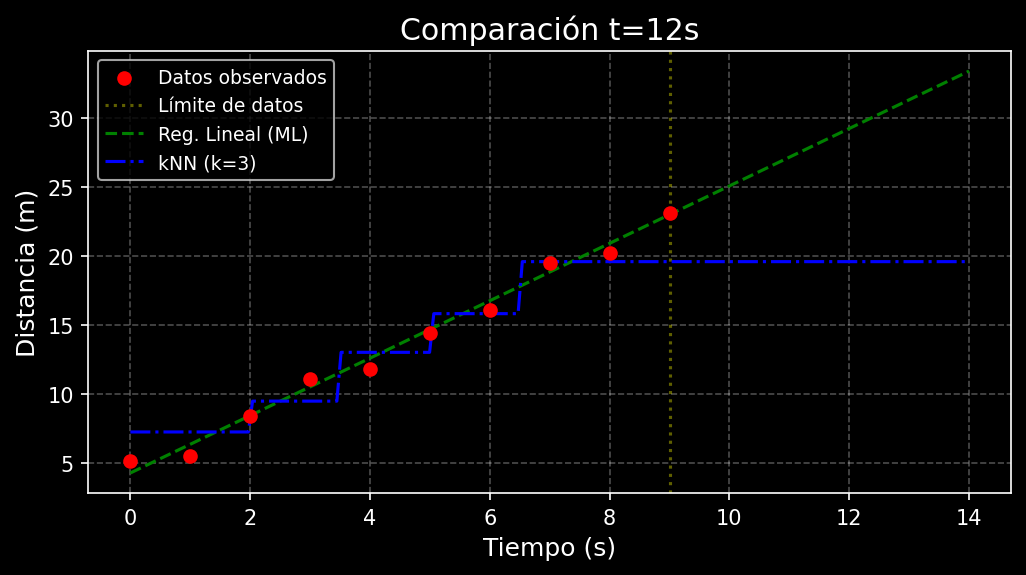

In [69]:
# Visualizamos los tres modelos en rango extendido
t_plot = np.linspace(0, 14, 200).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='red', zorder=5, label='Datos observados')
plt.axvline(x=x.max(), color='y', linestyle=':', alpha=0.5, label='Límite de datos')
#plt.plot(t_plot, bestm * t_plot + bestb, 'k-', label='Inferencia')
plt.plot(t_plot, regmodel.predict(t_plot), 'g--', label='Reg. Lineal (ML)')
plt.plot(t_plot, knnmodel.predict(t_plot), 'b-.', label='kNN (k=3)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Comparación t=12s')
plt.legend(fontsize=9)
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)

**Pregunta: ¿Qué le pasa a kNN en la zona t > 9? ¿Por qué? ¿Es un problema para este caso?**

**Tu respuesta:**

No tengo datos más allá de ese valor, ya que los datos van de 0 a 9. En cambio la regresión lineal aprendió que el problema es una relación lineal, y evalua los datos prediciendo una pendiente, que en éste caso es acertado ya que la relación entre la distancia y el tiempo es lineal. Por lo que para éste caso sería un problema para kNN ya que si evalua dependiendo de los vecinos cercanos, el modelo se estanca en el último valor, y no podemos predecir correctamente que pasa a tiempos mayores.

### 2d. ¿Importa el valor de k?

In [70]:
# Prueba distintos valores de k y compara el MSE en test
for k in [1, 2, 3, 5, 7]:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train.reshape(-1, 1), y_train)
    mse = np.mean((y_test - m.predict(X_test.reshape(-1, 1)))**2)
    pred_12 = m.predict([[12]])[0]
    print(f'k={k}  →  MSE test: {mse:.3f}  |  d(t=12): {pred_12:.2f} m')

k=1  →  MSE test: 3.557  |  d(t=12): 23.10 m
k=2  →  MSE test: 0.474  |  d(t=12): 21.30 m
k=3  →  MSE test: 1.241  |  d(t=12): 19.57 m
k=5  →  MSE test: 7.017  |  d(t=12): 16.32 m
k=7  →  MSE test: 24.559  |  d(t=12): 13.17 m


**Pregunta: ¿Cuál k elegirías? ¿Qué criterio usarías para elegirlo de forma sistemática?**

**Tu respuesta:**
El k=2, ya que es el que tiene el menor MSE. Pero sigue dependiento de la cantidad de datos que haya, para saber si es una decisión confiable.
---


## Conclusión

Completa la siguiente tabla comparando las dos estrategias:

| | Inferencia estadística | Machine Learning |
|---|---|---|
| ¿Necesita conocer el modelo físico? | si, en este caso problema lineal.|No, aprende de los datos.|
| ¿Entrega los parámetros del modelo? |si, en este caso intuímos v y d_0 |Regresión lineal si, pero no kNN |
| ¿Puede extrapolar fuera del rango de datos? |Utilizando chi cuadrado|Regresión lineal si, pero no kNN |
| ¿Cómo maneja las incertezas? |Utilizando chi-cuadrado| Las usa por defecto|
| ¿Cuándo la usarías en tu investigación? |Cuando se conoce de antemano el modelo físico|Cuando hay muchos datos y no se sabe el modelo físico|

**Pregunta final:** Si la relación fuera sinusoidal en vez de lineal (por ejemplo,
el movimiento de un péndulo), ¿qué estrategia funcionaría mejor?
Prueba cambiando `y = 2*x + 5 + ruido` por `y = np.sin(x) + ruido` al inicio.

**Tu respuesta:**

Podemos asumir que el problema es un movimiento armonico simple, al que conocemos sus soluciones para posición y velocidad. Luego en éste caso el modelo de kNN se ajustaría mejor que el de regresión lineal, aunque no del todo preciso.

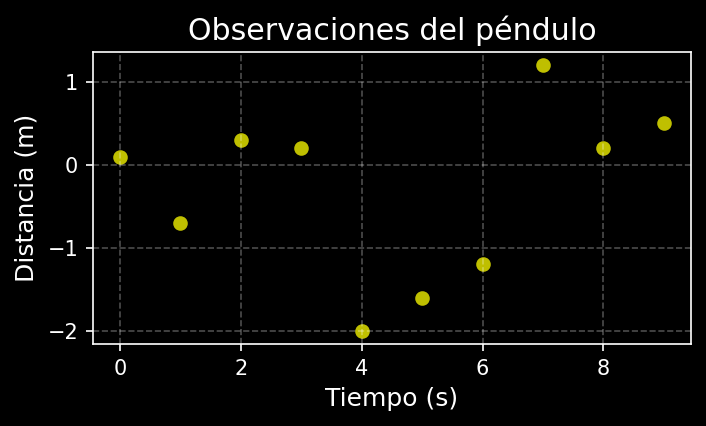

In [57]:
# Prueba sinusoidal
np.random.seed(16)  # semilla fija para reproducibilidad

x = np.arange(10)
y = 1*np.sin(x) + np.random.randn(10)  # datos con scatter gaussiano
y = np.round(y, 1)

# Visualiza los datos
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='y')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Observaciones del péndulo')
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)

In [23]:
# Definimos la grilla de parámetros a explorar
A_range = np.linspace(0, 5, 100)   # posibles amplitudes iniciales
W_range = np.linspace(0, 2*np.pi, 100)  # posibles velocidades angulares iniciales

best_mse = np.inf
bestA, bestW = 0, 0

# Completa el loop: para cada combinación (m, b),
# calcula el MSE y guarda los mejores parámetros
for a in A_range:
    for w in W_range:
      # Tu código acá:
      # Calculamos la posición:
      d = a * np.sin(w * x) # Solución M.A.S
      # Calculamos el error cuadrático medio
      mse = np.mean((y - d)**2)
      # encontramos el mejor mse como el valor dode el error sea mínimo.
      best_mse = min(best_mse, mse)
      # si es igual al modelo, se asignan esos valores
      if best_mse == mse:
        bestA = a
        bestW = w




print(f'Mejor Amplitud:     {bestA:.3f} m')
print(f'Mejor Frecuencia angular: {bestW:.3f} rad/s')
print(f'MSE mínimo: {best_mse:.4f}')

d12 = bestA * np.sin(bestW * 12)
print(f'd(t=12): {d12:.2f} m')

Mejor Amplitud:     0.960 m
Mejor Frecuencia angular: 5.839 rad/s
MSE mínimo: 0.6469
d(t=12): 0.78 m


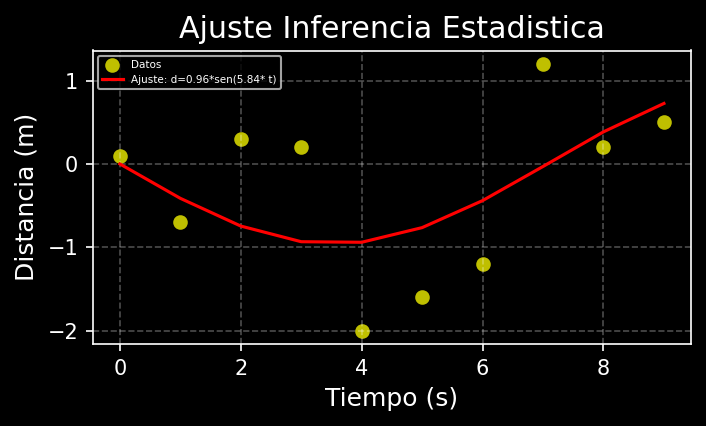

In [24]:
# Grafica los datos y la recta con los mejores parámetros
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='y', label='Datos')
plt.plot(x, bestA * np.sin(bestW * x), c='r', label=f'Ajuste: d={bestA:.2f}*sen({bestW:.2f}* t)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Ajuste Inferencia Estadistica')
plt.legend(fontsize=5)
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=3)

regmodel = LinearRegression()
knnmodel = KNeighborsRegressor(n_neighbors=2)

# Entrenamos con los datos de train y predecimos en test
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
y_pred_knn = knnmodel.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1)) # Tu código acá

print('Real:        ', y_test)
print('Reg. Lineal: ', np.round(y_pred_reg, 2))
print('kNN (k=3):   ', np.round(y_pred_knn, 2))

# Calculamos el MSE para cada modelo
mse_reg = np.mean((y_test - y_pred_reg)**2)
mse_knn = np.mean((y_test - y_pred_knn)**2)

print(f'MSE Regresión Lineal: {mse_reg:.4f}')
print(f'MSE kNN (k=3):        {mse_knn:.4f}')

Real:         [ 0.1  0.2 -1.2]
Reg. Lineal:  [-0.92  0.2  -0.08]
kNN (k=3):    [-0.2   0.85 -0.2 ]
MSE Regresión Lineal: 0.7667
MSE kNN (k=3):        0.5042


In [47]:
t_nuevo = np.array(12).reshape(-1, 1)

pred_reg = regmodel.predict(t_nuevo)[0]
pred_knn = knnmodel.predict(t_nuevo)[0]
pred_inf = bestA * np.sin(bestW* 12)

print(f'Inferencia estadística: {pred_inf:.2f} m')
print(f'Regresión lineal (ML):  {pred_reg:.2f} m')
print(f'kNN (k=3):              {pred_knn:.2f} m')
print(f'VAlor reald(t=12): {d12:.2f} m')

Inferencia estadística: 0.78 m
Regresión lineal (ML):  0.76 m
kNN (k=3):              0.85 m
VAlor reald(t=12): 0.78 m


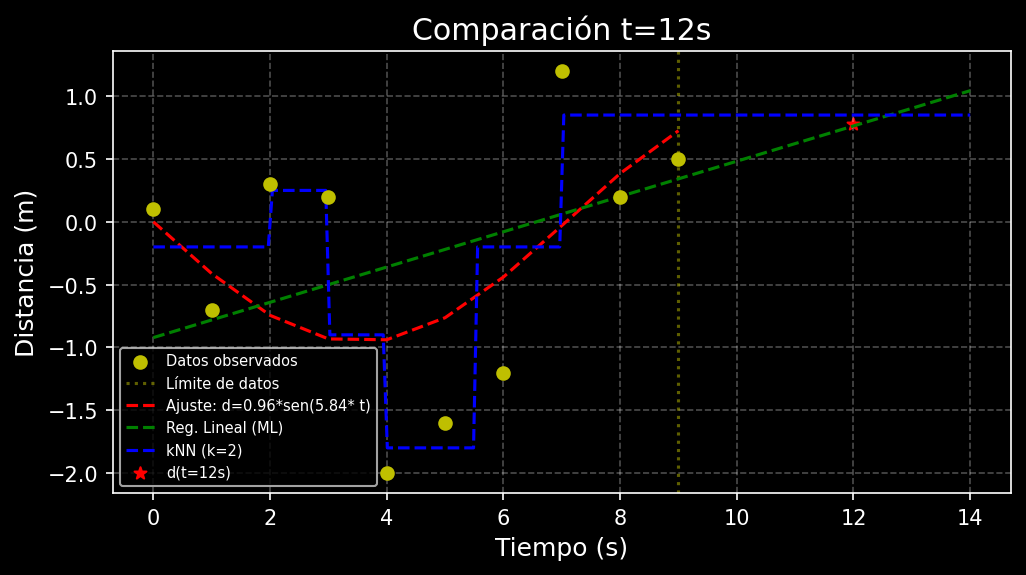

In [56]:
# Visualizamos los tres modelos en rango extendido
t_plot = np.linspace(0, 14, 200).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='y', zorder=5, label='Datos observados')
plt.axvline(x=x.max(), color='y', linestyle=':', alpha=0.5, label='Límite de datos')
plt.plot(x, bestA * np.sin(bestW * x), 'r--', label=f'Ajuste: d={bestA:.2f}*sen({bestW:.2f}* t)')
#plt.plot(t_plot, bestm * t_plot + bestb, 'k-', label='Inferencia')
plt.plot(t_plot, regmodel.predict(t_plot), 'g--', label='Reg. Lineal (ML)')
plt.plot(t_plot, knnmodel.predict(t_plot), 'b--', label='kNN (k=2)')
plt.scatter(12, d12, c='red', marker='*', label='d(t=12s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Comparación t=12s')
plt.legend(fontsize=7)
plt.tight_layout()
plt.grid(linestyle='--', linewidth=0.8, alpha=0.3)